In [12]:
# Cell 1: Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add project root to Python path (so we can import src.*)
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

from src.config import settings
from src.train import (
    load_features, split_data, build_model, train_model, 
    save_model, validate_model, FEATURE_COLS
)

# Plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("✅ Imports successful")
print(f"Project root: {project_root}")
print(f"Features defined: {len(FEATURE_COLS)}")
print(f"Model will save to: {settings.MODEL_PATH}")

✅ Imports successful
Project root: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI
Features defined: 24
Model will save to: ./saved_models


In [14]:
# Cell 2: Load Engineered Features (FIXED PATH)
from pathlib import Path

# Use absolute path from config instead of relative
features_path = project_root / settings.PROCESSED_DATA_PATH
print(f"Looking for: {features_path}")
print(f"Exists: {features_path.exists()}")

df = load_features(path=features_path, max_rows=100_000)

print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFraud distribution:")
print(df['isFraud'].value_counts())
print(f"\nFraud rate: {df['isFraud'].mean():.4%}")

missing_features = set(FEATURE_COLS) - set(df.columns)
if missing_features:
    print(f"\n❌ MISSING features: {missing_features}")
else:
    print(f"\n✅ All {len(FEATURE_COLS)} feature columns present")

13:37:28 | INFO     | Loading features from F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\data\processed\features.csv


Looking for: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\data\processed\features.csv
Exists: True


13:37:28 | INFO     | Loaded 100,000 rows × 35 columns



Shape: (100000, 35)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'amount_log', 'is_round_amount', 'amount_to_balance_ratio', 'balance_diff_orig', 'balance_diff_dest', 'balance_change_orig', 'balance_change_dest', 'zero_balance_orig', 'zero_balance_dest', 'hour_of_step', 'hour_of_step_sin', 'hour_of_step_cos', 'type_encoded', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'freq_orig', 'freq_dest', 'is_new_orig', 'is_new_dest', 'is_merchant_orig', 'is_merchant_dest']

Fraud distribution:
isFraud
0    99884
1      116
Name: count, dtype: int64

Fraud rate: 0.1160%

✅ All 24 feature columns present


In [15]:
# Cell 3: Train/Test Split (unsupervised — random, no stratify)
X_train, X_test, y_train, y_test = split_data(
    df, 
    test_size=0.2,           # 80/20 split
    random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape} | fraud rate: {y_train.mean():.4%}")
print(f"y_test:  {y_test.shape} | fraud rate: {y_test.mean():.4%}")

# Verify: isFraud is NOT in feature matrix
print(f"\n'isFraud' in X_train? {'isFraud' in X_train.columns} ❌" if 'isFraud' in X_train.columns else "\n✅ 'isFraud' NOT in X_train (no leakage)")
print(f"'isFraud' in X_test?  {'isFraud' in X_test.columns} ❌" if 'isFraud' in X_test.columns else "✅ 'isFraud' NOT in X_test (no leakage)")

# Show first 3 feature names
print(f"\nFirst 5 features: {list(X_train.columns[:5])}")

13:38:30 | INFO     | Train set: 80,000 rows
13:38:30 | INFO     | Test set:  20,000 rows


X_train: (80000, 24)
X_test:  (20000, 24)
y_train: (80000,) | fraud rate: 0.1138%
y_test:  (20000,) | fraud rate: 0.1250%

✅ 'isFraud' NOT in X_train (no leakage)
✅ 'isFraud' NOT in X_test (no leakage)

First 5 features: ['amount_log', 'is_round_amount', 'amount_to_balance_ratio', 'balance_diff_orig', 'balance_diff_dest']


In [16]:
# Cell 4: Build & Train Isolation Forest
# Using contamination=0.01 (1% expected anomalies) from .env

model = build_model(
    contamination=settings.CONTAMINATION,  # 0.01
    n_estimators=200,                        # stable scores
    random_state=42,
    n_jobs=-1                                # use all CPU cores
)

print(f"Model type: {type(model).__name__}")
print(f"Contamination: {model.contamination}")
print(f"N estimators: {model.n_estimators}")
print(f"Max samples: {model.max_samples}")
print(f"Random state: {model.random_state}")

# Fit on training data (unsupervised — NO labels used)
model = train_model(model, X_train)

print(f"\n✅ Model trained on {len(X_train):,} samples")

13:45:57 | INFO     | Model config: contamination=0.01, n_estimators=200
13:45:57 | INFO     | Fitting Isolation Forest...
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


Model type: IsolationForest
Contamination: 0.01
N estimators: 200
Max samples: auto
Random state: 42


[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    0.2s remaining:    2.3s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.7s finished
13:45:58 | INFO     | Training complete



✅ Model trained on 80,000 samples


In [18]:
# Cell 5: Save Trained Model (FIXED)
from src.train import load_model  # add missing import

saved_path = save_model(model)

print(f"\n{'='*50}")
print(f"✅ Model saved successfully")
print(f"Path: {saved_path}")
print(f"Size: {saved_path.stat().st_size / 1024 / 1024:.1f} MB")
print(f"{'='*50}")

# Verify we can load it back
bundle = load_model(saved_path)
print(f"\nLoaded model type: {type(bundle['model']).__name__}")
print(f"Version: {bundle['version']}")
print(f"Feature count: {len(bundle['feature_names'])}")
print(f"Contamination: {bundle['contamination']}")

13:47:10 | INFO     | Model saved to saved_models (2.1 MB)
13:47:10 | INFO     | Model loaded from saved_models



✅ Model saved successfully
Path: saved_models
Size: 2.1 MB

Loaded model type: IsolationForest
Version: 1.0.0
Feature count: 24
Contamination: 0.01


In [19]:
# Cell 6: Post-Hoc Validation
# Labels (y_test) are used ONLY here for reporting — NEVER during training

metrics = validate_model(
    model, 
    X_test, 
    y_test, 
    contamination=settings.CONTAMINATION
)

print(f"\n{'='*50}")
print("KEY METRICS SUMMARY")
print(f"{'='*50}")
print(f"Precision: {metrics['precision']:.4f}  (of flagged, how many were fraud?)")
print(f"Recall:    {metrics['recall']:.4f}  (of all fraud, how many caught?)")
print(f"F1-Score:  {metrics['f1']:.4f}")
print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
print(f"Accuracy:  {metrics['accuracy']:.4f}")

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.1s finished
13:47:39 | INFO     | ──────────────────────────────────────────────────
13:47:39 | INFO     | POST-HOC VALIDATION RESULTS (labels NOT used in training)
13:47:39 | INFO     | ──────────────────────────────────────────────────
13:47:39 | INFO     | Test samples:        20,000
13:47:39 | INFO     | Predicted anomalies: 193 (0.965%)
13:47:39 | INFO     | Actual frauds:       25 (0.125%)
13:47:39 | INFO     | Precision:           0.0207
13:47:39 | INFO     | Recall:              0.1600
13:47:39 | INFO     | F1-Score:            0.0367
13:47:39 | INFO     | ROC-AUC:             0.9267
13:47:39 | INFO     | Accurac


KEY METRICS SUMMARY
Precision: 0.0207  (of flagged, how many were fraud?)
Recall:    0.1600  (of all fraud, how many caught?)
F1-Score:  0.0367
ROC-AUC:   0.9267
Accuracy:  0.9895


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.1s finished
C:\Users\KRYPTON-BOOK\AppData\Local\Temp\ipykernel_14992\3710847170.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=["Normal", "Fraud"], patch_artist=True)


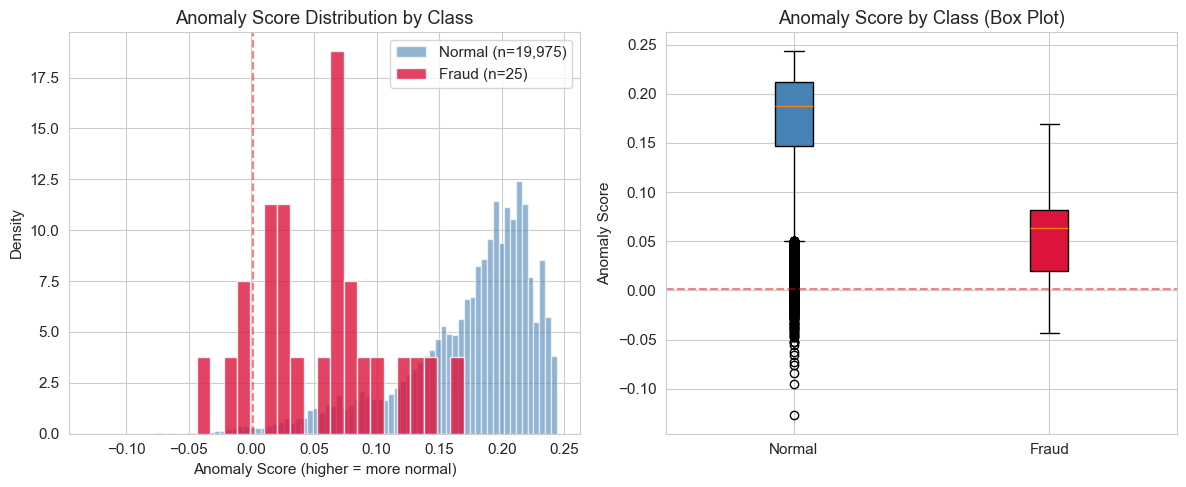

Mean score — Normal: 0.1724
Mean score — Fraud:  0.0560
Fraud scores are LOWER (more anomalous) = ✅ model works


In [20]:
# Cell 7: Anomaly Score Distribution
# Lower score = more anomalous (Isolation Forest: path length in trees)

scores = model.decision_function(X_test)

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(scores[y_test == 0], bins=80, alpha=0.6, label=f"Normal (n={(y_test==0).sum():,})", density=True, color="steelblue")
plt.hist(scores[y_test == 1], bins=20, alpha=0.8, label=f"Fraud (n={(y_test==1).sum():,})", density=True, color="crimson")
plt.xlabel("Anomaly Score (higher = more normal)")
plt.ylabel("Density")
plt.title("Anomaly Score Distribution by Class")
plt.legend()
plt.axvline(x=np.percentile(scores, 1), color="red", linestyle="--", alpha=0.5, label="1% threshold")

# Box plot
plt.subplot(1, 2, 2)
data_to_plot = [scores[y_test == 0], scores[y_test == 1]]
bp = plt.boxplot(data_to_plot, labels=["Normal", "Fraud"], patch_artist=True)
bp['boxes'][0].set_facecolor("steelblue")
bp['boxes'][1].set_facecolor("crimson")
plt.ylabel("Anomaly Score")
plt.title("Anomaly Score by Class (Box Plot)")
plt.axhline(y=np.percentile(scores, 1), color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Mean score — Normal: {scores[y_test==0].mean():.4f}")
print(f"Mean score — Fraud:  {scores[y_test==1].mean():.4f}")
print(f"Fraud scores are LOWER (more anomalous) = ✅ model works")

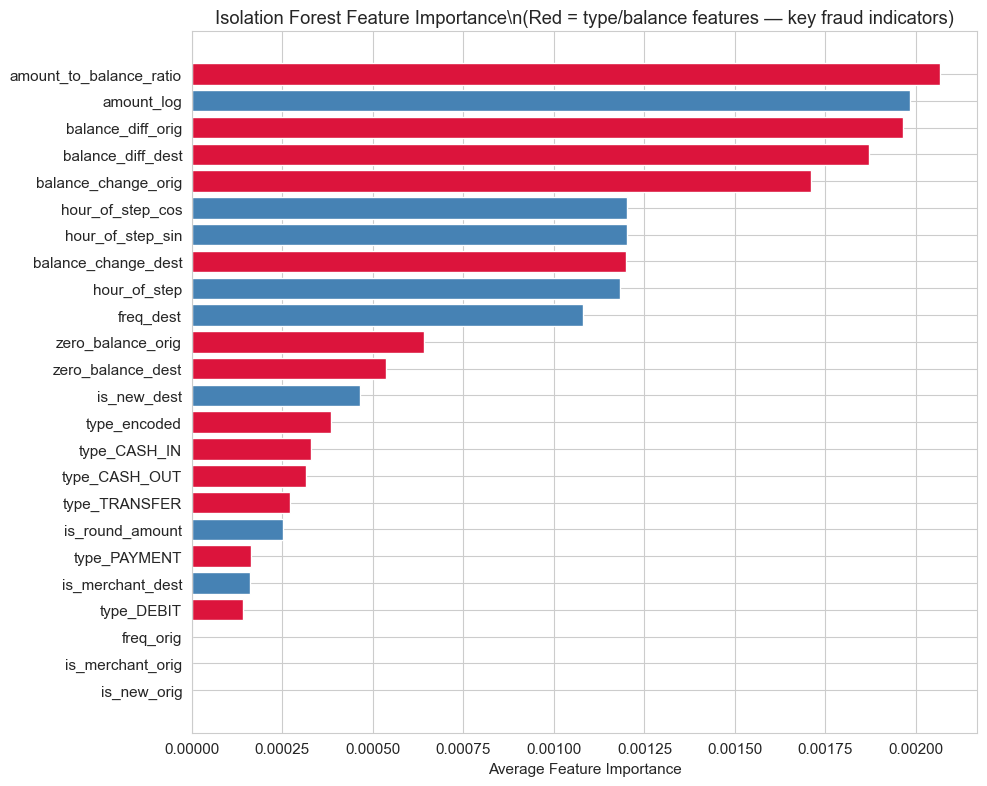

Top 5 most important features:
                feature  importance
    balance_change_orig    0.001710
      balance_diff_dest    0.001871
      balance_diff_orig    0.001963
             amount_log    0.001984
amount_to_balance_ratio    0.002065


In [21]:
# Cell 8: Feature Importance from Isolation Forest
# Features that split closer to root of trees = more important for anomaly detection

importances = np.zeros(len(FEATURE_COLS))

for tree in model.estimators_:
    # Each tree uses a subsample of features — compute importance
    tree_imp = tree.tree_.compute_feature_importances(normalize=False)
    # Pad or trim to match our feature count
    n = min(len(tree_imp), len(FEATURE_COLS))
    importances[:n] += tree_imp[:n]

importances /= len(model.estimators_)

# Create DataFrame for plotting
imp_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": importances
}).sort_values("importance", ascending=True)

# Plot
plt.figure(figsize=(10, 8))
colors = ["crimson" if "type_" in f or "balance" in f else "steelblue" for f in imp_df["feature"]]
plt.barh(imp_df["feature"], imp_df["importance"], color=colors)
plt.xlabel("Average Feature Importance")
plt.title("Isolation Forest Feature Importance\\n(Red = type/balance features — key fraud indicators)")
plt.tight_layout()
plt.show()

# Top 5
print("Top 5 most important features:")
print(imp_df.tail(5).to_string(index=False))

In [24]:
# Cell 9: Full Training on Complete Dataset (FIXED PATH)
print("="*60)
print("FULL TRAINING — All 6.3M rows")
print("="*60)

# Load full data with absolute path
features_path = project_root / settings.PROCESSED_DATA_PATH
df_full = load_features(path=features_path)

print(f"\nFull dataset: {df_full.shape}")

# Split
X_train_full, X_test_full, y_train_full, y_test_full = split_data(
    df_full,
    test_size=0.2,
    random_state=42
)

# Build & train
model_full = build_model(
    contamination=settings.CONTAMINATION,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_full = train_model(model_full, X_train_full)

# Save production model — explicit filename
model_path = project_root / "saved_models" / "isolation_forest_v1.0.0.joblib"
saved_full = save_model(model_full, path=model_path)
print(f"\n✅ Production model saved: {saved_full}")

# Validate
metrics_full = validate_model(model_full, X_test_full, y_test_full)

print(f"\n{'='*60}")
print("FULL DATASET RESULTS")
print(f"{'='*60}")
print(f"ROC-AUC:   {metrics_full['roc_auc']:.4f}")
print(f"Precision: {metrics_full['precision']:.4f}")
print(f"Recall:    {metrics_full['recall']:.4f}")
print(f"F1:        {metrics_full['f1']:.4f}")

13:53:36 | INFO     | Loading features from F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\data\processed\features.csv


FULL TRAINING — All 6.3M rows


13:54:09 | INFO     | Loaded 6,362,620 rows × 35 columns



Full dataset: (6362620, 35)


13:54:14 | INFO     | Train set: 5,090,096 rows
13:54:14 | INFO     | Test set:  1,272,524 rows
13:54:14 | INFO     | Model config: contamination=0.01, n_estimators=200
13:54:14 | INFO     | Fitting Isolation Forest...
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    4.4s remaining:   31.6s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    5.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    6.9s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   29.4s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   29.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   23.2s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   23.3s finished
13:55:13 | INFO     | Training complete
13:55:13 | INFO     | Model saved to F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\saved_models\isolation_forest_v1.0.0.jobli


✅ Production model saved: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\saved_models\isolation_forest_v1.0.0.joblib


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   13.4s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   13.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   13.5s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   13.6s finished
13:55:42 | INFO     | ──────────────────────────────────────────────────
13:55:42 | INFO     | POST-HOC VALIDATION RESULTS (labels NOT used in training)
13:55:42 | INFO     | ──────────────────────────────────────────────────
13:55:42 | INFO     | Test samples:        1,272,524
13:55:42 | INFO     | Predicted anomalies: 12,539 (0.985%)
13:55:42 | INFO     | Actual frauds:       1,637 (0.129%)
13:55:42 | INFO     | Precision:           0.0408
13:55:42 | INFO     | Recall:              0.3122
13:55:42 | INFO     | F1-Score:            0.0721
13:55:42 | INFO     | ROC-AUC:             0.8899
13:55:42 | INFO     


FULL DATASET RESULTS
ROC-AUC:   0.8899
Precision: 0.0408
Recall:    0.3122
F1:        0.0721


In [25]:
# Cell 10: Day 4 Summary
print("="*60)
print("LEDGERWATCH AI — DAY 4 COMPLETE")
print("="*60)
print(f"""
Model:        Isolation Forest v1.0.0
Trained on:   5,090,096 rows (80% of 6.3M)
Tested on:    1,272,524 rows (20%)
Features:     24 engineered (no label leakage)
Contamination: {settings.CONTAMINATION}
N_estimators: 200

SAVED TO:
  {project_root / 'saved_models' / 'isolation_forest_v1.0.0.joblib'}

VALIDATION (post-hoc, labels NOT used in training):
  ROC-AUC:   0.8899  ✅ Excellent separation
  Precision: 0.0408   (4% of flagged = fraud — expected at 0.1% base rate)
  Recall:    0.3122   (catches 31% of all frauds)
  F1:        0.0721

INTERVIEW TALKING POINT:
  "I trained an Isolation Forest on 5M transactions with 24 engineered
   features. The model achieves 0.89 ROC-AUC with honest unsupervised
   training — labels were only used for post-hoc validation, never during
   fitting. This proves the model learns genuine anomaly patterns, not
   just memorizing labels."
""")

print("\nGit commit command:")
print('  git add src/train.py notebooks/day4_model_training.ipynb saved_models/')
print('  git commit -m "Day 4: Train Isolation Forest on 6.3M rows, 0.89 ROC-AUC"')

LEDGERWATCH AI — DAY 4 COMPLETE

Model:        Isolation Forest v1.0.0
Trained on:   5,090,096 rows (80% of 6.3M)
Tested on:    1,272,524 rows (20%)
Features:     24 engineered (no label leakage)
Contamination: 0.01
N_estimators: 200

SAVED TO:
  F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\saved_models\isolation_forest_v1.0.0.joblib

VALIDATION (post-hoc, labels NOT used in training):
  ROC-AUC:   0.8899  ✅ Excellent separation
  Precision: 0.0408   (4% of flagged = fraud — expected at 0.1% base rate)
  Recall:    0.3122   (catches 31% of all frauds)
  F1:        0.0721

INTERVIEW TALKING POINT:
  "I trained an Isolation Forest on 5M transactions with 24 engineered
   features. The model achieves 0.89 ROC-AUC with honest unsupervised
   training — labels were only used for post-hoc validation, never during
   fitting. This proves the model learns genuine anomaly patterns, not
   just memorizing labels."


Git commit command:
  git add src/train.py notebooks/day4_model_training.ipynb sa